In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,accuracy_score)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb

In [3]:
e=pd.read_csv('/content/exercise.csv')
c=pd.read_csv('/content/calories.csv')
df=pd.merge(e,c,on='User_ID')

In [4]:
e.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [5]:
c.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [6]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [8]:
df.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


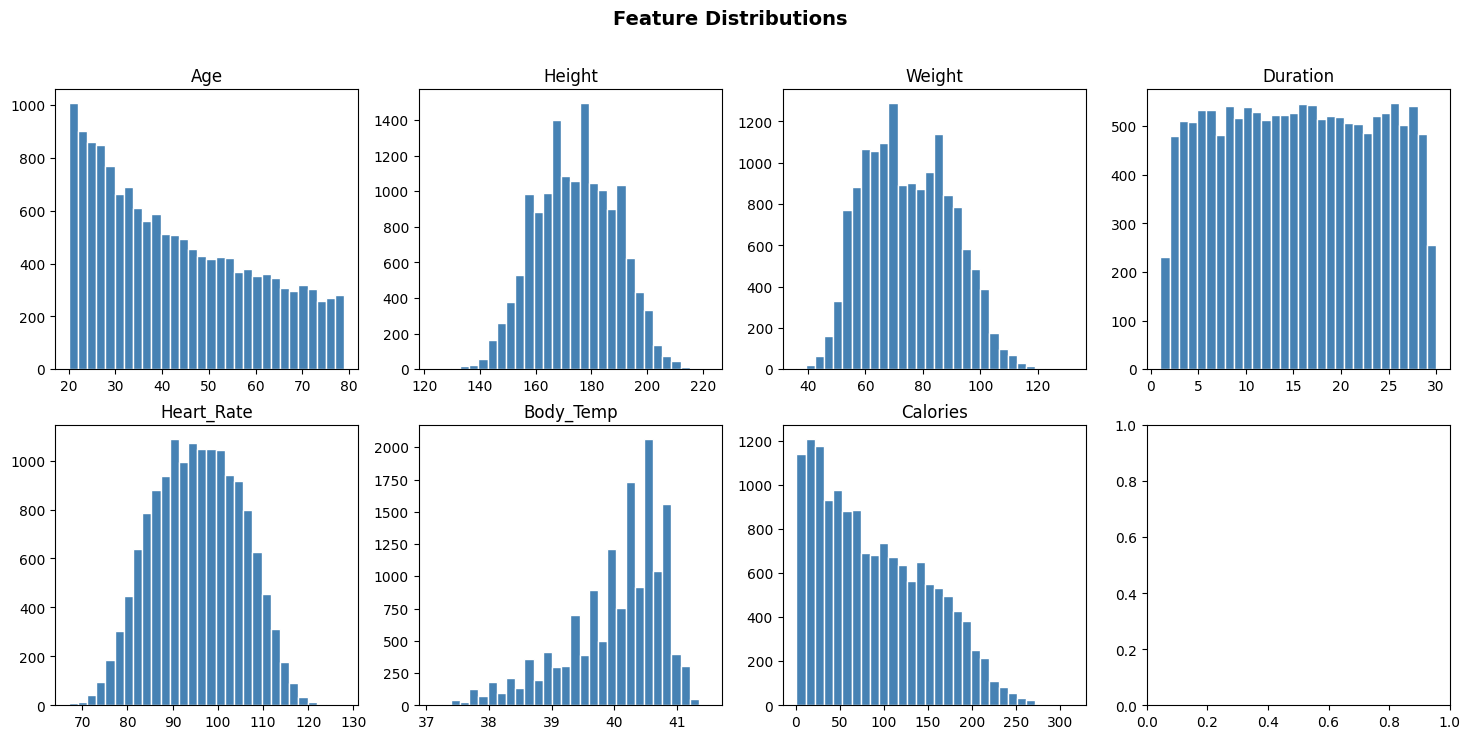

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Feature Distributions", fontsize=14, fontweight="bold")
num_cols = ["Age", "Height", "Weight", "Duration", "Heart_Rate", "Body_Temp", "Calories"]
for i, col in enumerate(num_cols):
    ax = axes[i // 4][i % 4]
    ax.hist(df[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)

In [11]:
sns.set()

/tmp/ipykernel_4474/74525228.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender',palette='coolwarm')


<Axes: xlabel='Gender', ylabel='count'>

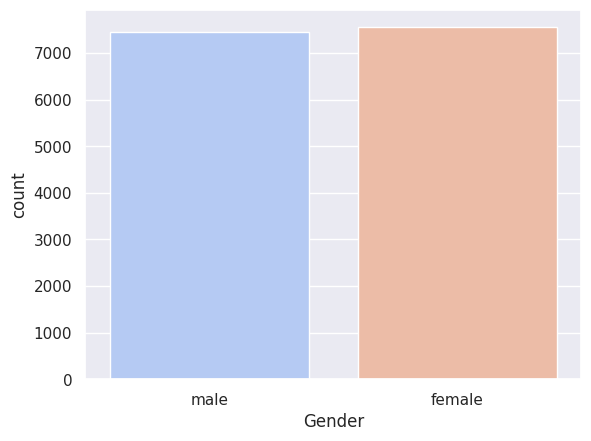

In [15]:
sns.countplot(data=df, x='Gender',palette='coolwarm')

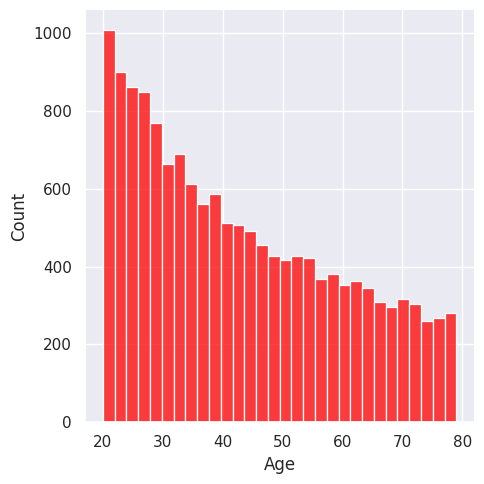

In [22]:
sns.displot(data=df, x='Age',bins=30,color='red')

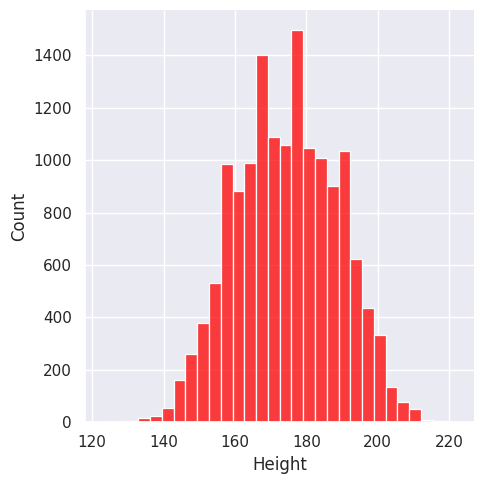

In [24]:
sns.displot(data=df, x='Height',bins=30,color='red')

In [28]:
plt.figure(figsize=(9, 6))
corr = df.drop(columns=["User_ID"]).copy()
corr["Gender"] = LabelEncoder().fit_transform(corr["Gender"])
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=120)
plt.close()
plt.show()

In [32]:
df.replace({'Gender':{'male':0,'female':1}},inplace=True)
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


seperating features and target
,test and train data


In [33]:
x=df.drop(['User_ID','Calories'],axis=1)
y=df['Calories']

In [34]:
x.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,0,68,190.0,94.0,29.0,105.0,40.8
1,1,20,166.0,60.0,14.0,94.0,40.3
2,0,69,179.0,79.0,5.0,88.0,38.7
3,1,34,179.0,71.0,13.0,100.0,40.5
4,1,27,154.0,58.0,10.0,81.0,39.8


In [35]:
y.head()

,Calories
0,231.0
1,66.0
2,26.0
3,71.0
4,35.0


In [36]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

linear regression


In [42]:
lr=LinearRegression()
lr.fit(xtrain,ytrain)
lrpred=lr.predict(xtest)
lrmae=mean_absolute_error(ytest,lrpred)
lrmse=np.sqrt(mean_squared_error(ytest,lrpred))
lrr2=r2_score(ytest,lrpred)
print('MAE:',lrmae)
print('RMSE:',lrmse)
print('R2_score:',lrr2)

MAE: 8.44151355384971
RMSE: 11.488940149152876
R2_score: 0.9672937151257295


ridge regression

In [43]:
rr=Ridge()
rr.fit(xtrain,ytrain)
rrpred=rr.predict(xtest)
rrmae=mean_absolute_error(ytest,rrpred)
rrrmse=np.sqrt(mean_squared_error(ytest,rrpred))
rrr2=r2_score(ytest,rrpred)
print('MAE:',rrmae)
print('RMSE:',rrrmse)
print('R2_score:',rrr2)

MAE: 8.441411841419178
RMSE: 11.488962487161038
R2_score: 0.9672935879435944


Support Vector Regressor

In [45]:
svr=SVR()
svr.fit(xtrain,ytrain)
svpred=svr.predict(xtest)
svmae=mean_absolute_error(ytest,svpred)
svrmse=np.sqrt(mean_squared_error(ytest,svpred))
svr2=r2_score(ytest,svpred)
print('MAE:',svmae)
print('RMSE:',svrmse)
print('R2_score:',svr2)

MAE: 10.873747807130613
RMSE: 15.969724886598339
R2_score: 0.9368074107926527


random forest


In [46]:
rf=RandomForestRegressor()
rf.fit(xtrain,ytrain)
rfpred=rf.predict(xtest)
rfmae=mean_absolute_error(ytest,rfpred)
rfr2=r2_score(ytest,rfpred)
rfrmse=np.sqrt(mean_squared_error(ytest,rfpred))
print('MAE:',rfmae)
print('R2_score:',rfr2)
print('RMSE:',rfrmse)

MAE: 1.7104933333333332
R2_score: 0.9982323086049578
RMSE: 2.6709612252271024


xgboost


In [47]:
xgb=xgb.XGBRegressor()
xgb.fit(xtrain,ytrain)
xgbpred=xgb.predict(xtest)
xgbmae=mean_absolute_error(ytest,xgbpred)
xgbrmse=np.sqrt(mean_squared_error(ytest,xgbpred))
xgb2=r2_score(ytest,xgbpred)
print('MAE:',xgbmae)
print('R2_score:',xgb2)
print('RMSE:',xgbrmse)

MAE: 1.4981198125282924
R2_score: 0.9988678909361673
RMSE: 2.1375116634132594


save best model

In [49]:
import pickle
pickle.dump(xgb,open('model.pkl','wb'))
pickle.dump(df,open('df.pkl','wb'))

In [51]:
from google.colab import files

files.download("model.pkl")
files.download("df.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>